# NB03 — Evidence Stratification

**Question:** Does PharmGKB evidence quality predict FAERS signal strength?

**Prediction:** Higher-quality PharmGKB annotations (1A > 1B > 2A/2B > 3 > 4)
should correspond to stronger FAERS disproportionality signals (higher ROR) for
the matched adverse events. If true, this demonstrates that the method is
*calibrated* — the enrichment signal is not uniform noise, but tracks with the
biological credibility of the underlying genomic annotation.

**Design:** Across all 2,163 matched drug-AE pairs from NB01, group by
PharmGKB evidence level and compare ROR distributions. Then recompute
per-stratum fold enrichment using only annotations at each tier as the
'annotated' set (pooled across all drugs).

**Caveat upfront:** The 1A/1B tiers have far fewer matched pairs (n=76 and n=5
respectively after confidence filtering) than tier 3 (n≈1,500). Tier 3 is also
where the Bonferroni survivors from NB02 sit. The analysis tests calibration;
any tier-level p-values are secondary to the directional trend.

In [1]:
import sys, os
from pathlib import Path
root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
os.chdir(root)

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

FIGURES_DIR = Path('data/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

signals = pd.read_csv('data/signals_pgx_drugs.csv')
matched = pd.read_csv('data/enrichment_results.csv')

# Work with high-confidence matches throughout
MIN_CONF = 0.5
m = matched[matched['MATCH_CONFIDENCE'] >= MIN_CONF].copy()
m['log2_ror'] = np.log2(m['ROR'].clip(0.1))

# Evidence tier ordering
EV_ORDER  = ['1A', '1B', '2A', '2B', '3', '4']
EV_LABELS = {'1A': '1A (FDA label)', '1B': '1B (replicated)', '2A': '2A',
             '2B': '2B', '3': '3 (candidate)', '4': '4 (preliminary)'}
EV_COLORS = {'1A': '#1a237e', '1B': '#1565c0', '2A': '#1976d2',
             '2B': '#42a5f5', '3':  '#90caf9', '4':  '#bbdefb'}

m['EVIDENCE_LEVEL'] = m['EVIDENCE_LEVEL'].astype(str).str.strip()
m_valid = m[m['EVIDENCE_LEVEL'].isin(EV_ORDER)].copy()

print(f'Matched pairs (conf ≥ {MIN_CONF}): {len(m):,}')
print()
tier_counts = m_valid['EVIDENCE_LEVEL'].value_counts().reindex(EV_ORDER).dropna().astype(int)
print('Pairs per evidence tier:')
for tier, n in tier_counts.items():
    print(f'  {EV_LABELS[tier]:<22}  n={n}')

Matched pairs (conf ≥ 0.5): 1,717

Pairs per evidence tier:
  1A (FDA label)          n=60
  1B (replicated)         n=2
  2A                      n=15
  2B                      n=9
  3 (candidate)           n=1524
  4 (preliminary)         n=107


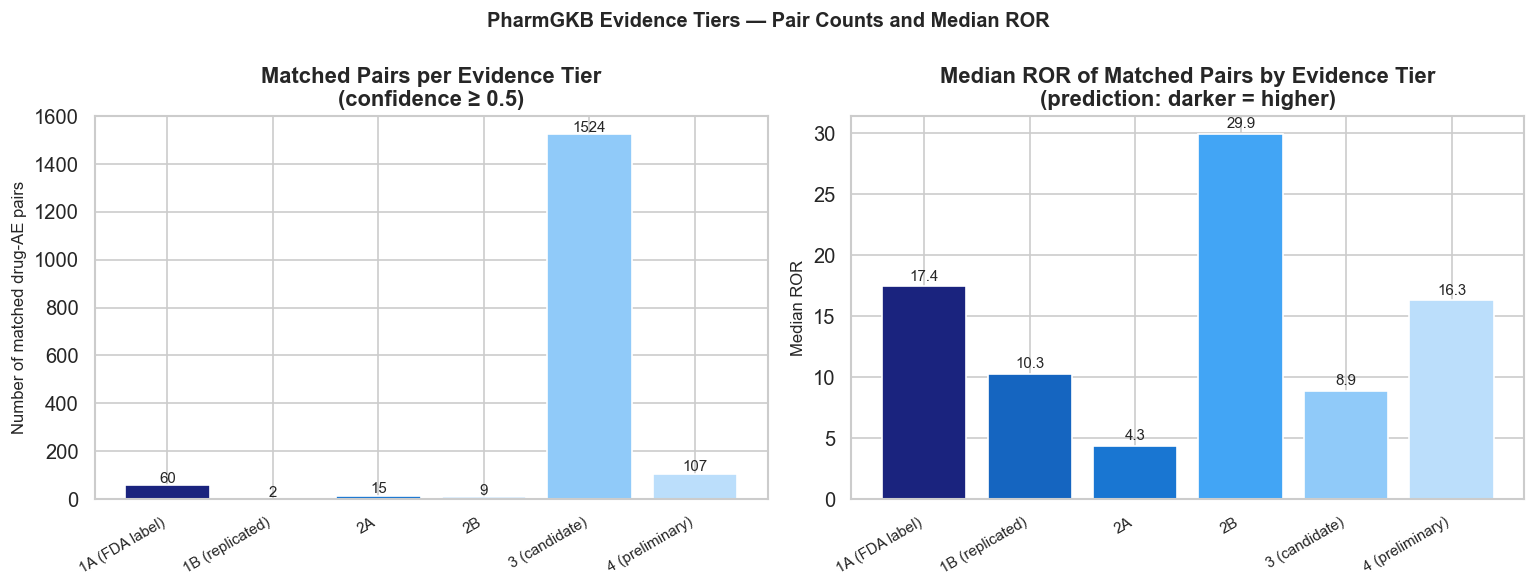

Median ROR by tier:
  1A (FDA label)          median ROR =   17.4  (n=60)
  1B (replicated)         median ROR =   10.3  (n=2)
  2A                      median ROR =    4.3  (n=15)
  2B                      median ROR =   29.9  (n=9)
  3 (candidate)           median ROR =    8.9  (n=1524)
  4 (preliminary)         median ROR =   16.3  (n=107)


In [2]:
# -- Figure 1: tier counts + median ROR per tier --------------------------------
tiers_present = [t for t in EV_ORDER if t in m_valid['EVIDENCE_LEVEL'].values]
tier_stats = (m_valid.groupby('EVIDENCE_LEVEL')['log2_ror']
              .agg(['count', 'median', 'mean', 'std'])
              .reindex(tiers_present))
tier_stats['median_ror'] = 2 ** tier_stats['median']
tier_stats['mean_ror']   = 2 ** tier_stats['mean']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: pair counts
bar_colors = [EV_COLORS[t] for t in tiers_present]
bars = ax1.bar([EV_LABELS[t] for t in tiers_present],
               tier_stats['count'], color=bar_colors, edgecolor='white')
for bar, val in zip(bars, tier_stats['count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(int(val)), ha='center', fontsize=9)
ax1.set_ylabel('Number of matched drug-AE pairs', fontsize=10)
ax1.set_title('Matched Pairs per Evidence Tier\n(confidence ≥ 0.5)', fontweight='bold')
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right', fontsize=9)

# Right: median ROR per tier
ax2.bar([EV_LABELS[t] for t in tiers_present],
        tier_stats['median_ror'], color=bar_colors, edgecolor='white')
for i, (tier, row) in enumerate(tier_stats.iterrows()):
    ax2.text(i, row['median_ror'] + 0.5, f'{row["median_ror"]:.1f}',
             ha='center', fontsize=9)
ax2.set_ylabel('Median ROR', fontsize=10)
ax2.set_title('Median ROR of Matched Pairs by Evidence Tier\n(prediction: darker = higher)', fontweight='bold')
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=9)

plt.suptitle('PharmGKB Evidence Tiers — Pair Counts and Median ROR', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb03_01_tier_overview.png')
plt.show()

print('Median ROR by tier:')
for tier in tiers_present:
    row = tier_stats.loc[tier]
    print(f'  {EV_LABELS[tier]:<22}  median ROR = {row["median_ror"]:6.1f}  (n={int(row["count"])})')

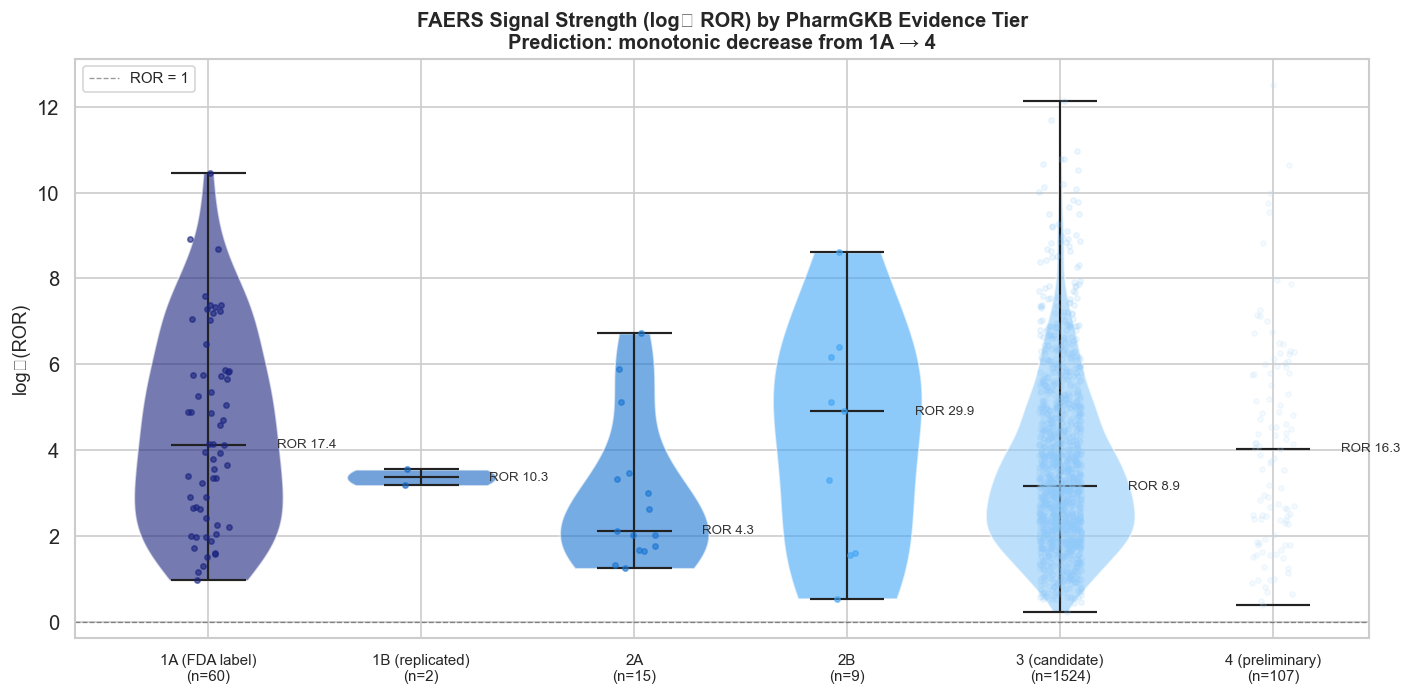

In [3]:
# -- Figure 2: violin plot of log2(ROR) per tier --------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

plot_data = [m_valid[m_valid['EVIDENCE_LEVEL'] == t]['log2_ror'].dropna().values
             for t in tiers_present]
tier_labels = [f'{EV_LABELS[t]}\n(n={len(d)})' for t, d in zip(tiers_present, plot_data)]

parts = ax.violinplot(plot_data, positions=range(len(tiers_present)),
                       showmedians=True, widths=0.7)

for i, (pc, t) in enumerate(zip(parts['bodies'], tiers_present)):
    pc.set_facecolor(EV_COLORS[t])
    pc.set_alpha(0.6)
for part in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
    parts[part].set_color('#222')
    parts[part].set_linewidth(1.3)

# Overlay individual points for small-n tiers
np.random.seed(0)
for i, (vals, t) in enumerate(zip(plot_data, tiers_present)):
    jitter = np.random.uniform(-0.1, 0.1, len(vals))
    alpha  = 0.6 if len(vals) < 100 else 0.15
    ax.scatter(i + jitter, vals, s=10, alpha=alpha,
               color=EV_COLORS[t], zorder=3)

ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4, label='ROR = 1')
ax.set_xticks(range(len(tiers_present)))
ax.set_xticklabels(tier_labels, fontsize=9)
ax.set_ylabel('log₂(ROR)', fontsize=11)
ax.set_title(
    'FAERS Signal Strength (log₂ ROR) by PharmGKB Evidence Tier\n'
    'Prediction: monotonic decrease from 1A → 4',
    fontsize=12, fontweight='bold'
)

# Annotate medians
for i, (vals, t) in enumerate(zip(plot_data, tiers_present)):
    med = np.median(vals)
    ax.text(i + 0.32, med, f'ROR {2**med:.1f}', va='center', fontsize=8, color='#333')

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb03_02_violin_by_tier.png')
plt.show()

In [4]:
# -- Pairwise Mann-Whitney tests between evidence tiers -------------------------
print('Pairwise Mann-Whitney U (alternative: higher tier > lower tier):')
print(f'{"Comparison":<30} {"U":>8}  {"p":>8}  {"Sig"}')
print('-' * 55)

tier_data = {t: m_valid[m_valid['EVIDENCE_LEVEL'] == t]['log2_ror'].dropna().values
             for t in tiers_present}

# Test each tier vs the next lower tier
for i in range(len(tiers_present) - 1):
    t_high = tiers_present[i]
    t_low  = tiers_present[i + 1]
    hi = tier_data[t_high]
    lo = tier_data[t_low]
    if len(hi) < 2 or len(lo) < 2:
        print(f'{EV_LABELS[t_high]} vs {EV_LABELS[t_low]:<15}  (insufficient data)')
        continue
    u, p = stats.mannwhitneyu(hi, lo, alternative='greater')
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    label = f'{EV_LABELS[t_high]} > {EV_LABELS[t_low]}'
    print(f'{label:<30} {u:>8.0f}  {p:>8.4f}  {sig}')

print()
# Most important comparison: 1A vs 3
if '1A' in tier_data and '3' in tier_data:
    u, p = stats.mannwhitneyu(tier_data['1A'], tier_data['3'], alternative='greater')
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f'{"1A (FDA label) vs 3 (candidate)":<30} {u:>8.0f}  {p:>8.4f}  {sig}')

Pairwise Mann-Whitney U (alternative: higher tier > lower tier):
Comparison                            U         p  Sig
-------------------------------------------------------
1A (FDA label) > 1B (replicated)       76    0.2797  n.s.
1B (replicated) > 2A                 22    0.1838  n.s.
2A > 2B                              54    0.7981  n.s.
2B > 3 (candidate)                 7938    0.2075  n.s.
3 (candidate) > 4 (preliminary)    71171    0.9861  n.s.

1A (FDA label) vs 3 (candidate)    56446    0.0010  **


In [5]:
# -- Stratified enrichment: per-tier fold enrichment vs unannotated ------------
# For each evidence tier, pooled across all drugs:
# annotated RORs (at this tier) vs unannotated RORs (same drugs)

strat_results = []

for tier in tiers_present:
    tier_pairs = m_valid[m_valid['EVIDENCE_LEVEL'] == tier]
    if len(tier_pairs) < 5:
        continue

    # Collect annotated RORs at this tier
    ann_rors = []
    unann_rors = []

    drugs_in_tier = tier_pairs['DRUG'].unique()
    for drug in drugs_in_tier:
        drug_tier_pts = set(tier_pairs[tier_pairs['DRUG'] == drug]['PT'])
        drug_all      = signals[signals['DRUG'] == drug]

        ann   = drug_all[drug_all['PT'].isin(drug_tier_pts)]['ROR'].dropna().values
        unann = drug_all[~drug_all['PT'].isin(drug_tier_pts)]['ROR'].dropna().values

        ann_rors.extend(ann)
        unann_rors.extend(unann)

    ann_rors   = np.array(ann_rors)
    unann_rors = np.array(unann_rors)

    if len(ann_rors) < 2 or len(unann_rors) < 2:
        continue

    med_ann   = np.median(ann_rors)
    med_unann = np.median(unann_rors)
    fold      = med_ann / max(med_unann, 0.01)
    u, p      = stats.mannwhitneyu(ann_rors, unann_rors, alternative='greater')

    strat_results.append({
        'tier':          tier,
        'n_annotated':   len(ann_rors),
        'n_unannotated': len(unann_rors),
        'median_ror_ann':   round(med_ann,   1),
        'median_ror_unann': round(med_unann, 1),
        'fold_enrichment':  round(fold, 2),
        'mannwhitney_p':    round(p, 6),
    })

strat_df = pd.DataFrame(strat_results)
strat_df['label'] = strat_df['tier'].map(EV_LABELS)

print('Stratified enrichment by evidence tier (pooled across all drugs):')
print()
print(strat_df[['label', 'n_annotated', 'median_ror_ann', 'median_ror_unann',
                 'fold_enrichment', 'mannwhitney_p']]
      .rename(columns={'label': 'Tier', 'n_annotated': 'Annotated AEs (n)',
                        'median_ror_ann': 'Median ROR (ann)',
                        'median_ror_unann': 'Median ROR (unann)',
                        'fold_enrichment': 'Fold enrichment',
                        'mannwhitney_p': 'p (Mann-Whitney)'})
      .to_string(index=False))

Stratified enrichment by evidence tier (pooled across all drugs):

           Tier  Annotated AEs (n)  Median ROR (ann)  Median ROR (unann)  Fold enrichment  p (Mann-Whitney)
 1A (FDA label)                 60              17.4                 8.0             2.18          0.000267
             2A                 15               4.3                 7.8             0.56          0.841624
             2B                  9              29.9                 4.5             6.68          0.028671
  3 (candidate)               1524               8.9                 6.8             1.31          0.000000
4 (preliminary)                107              16.3                 7.4             2.19          0.000363


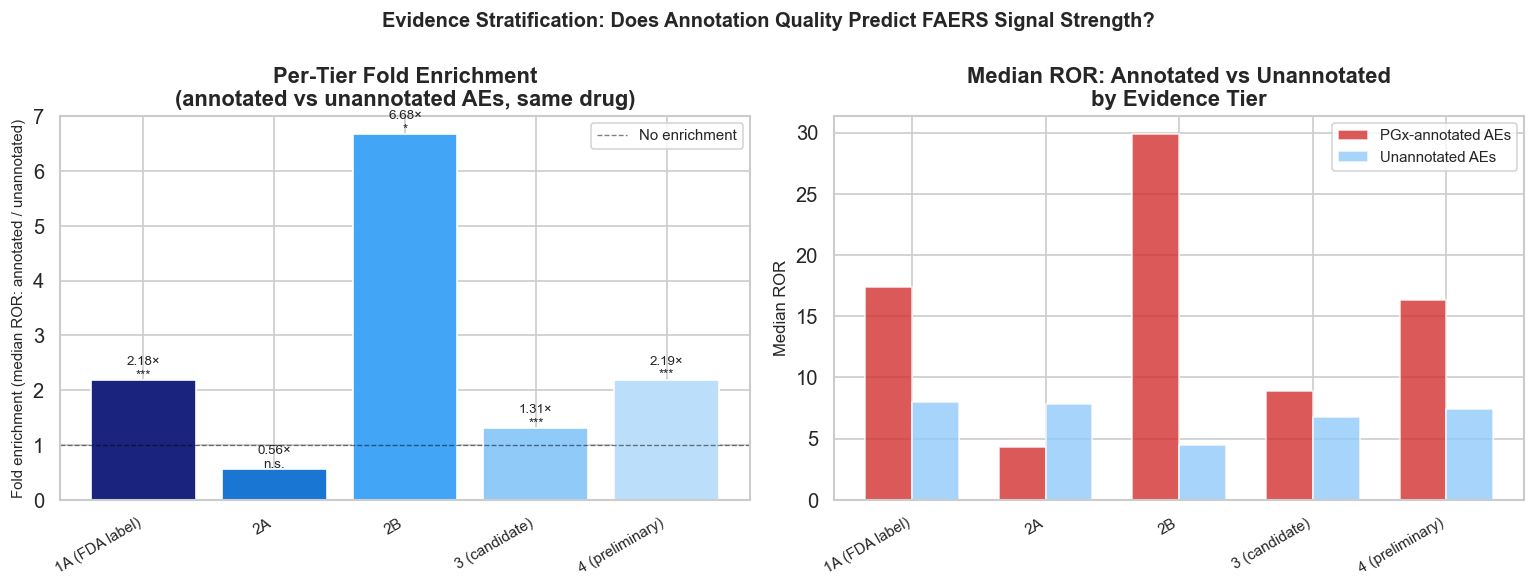

In [6]:
# -- Figure 3: stratified enrichment plot ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: fold enrichment by tier
bar_colors_strat = [EV_COLORS.get(t, '#888') for t in strat_df['tier']]
bars = axes[0].bar(strat_df['label'], strat_df['fold_enrichment'],
                    color=bar_colors_strat, edgecolor='white')
axes[0].axhline(1.0, color='black', lw=0.8, linestyle='--', alpha=0.5, label='No enrichment')

for bar, (_, row) in zip(bars, strat_df.iterrows()):
    sig = '***' if row['mannwhitney_p'] < 0.001 else '**' if row['mannwhitney_p'] < 0.01 \
          else '*' if row['mannwhitney_p'] < 0.05 else 'n.s.'
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.03,
                  f'{row["fold_enrichment"]:.2f}×\n{sig}',
                  ha='center', fontsize=8)

axes[0].set_ylabel('Fold enrichment (median ROR: annotated / unannotated)', fontsize=9)
axes[0].set_title('Per-Tier Fold Enrichment\n(annotated vs unannotated AEs, same drug)', fontweight='bold')
axes[0].legend(fontsize=9)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=9)

# Right: median ROR annotated vs unannotated, per tier
x = np.arange(len(strat_df))
width = 0.35
axes[1].bar(x - width/2, strat_df['median_ror_ann'],   width,
             label='PGx-annotated AEs', color='#d32f2f', alpha=0.8)
axes[1].bar(x + width/2, strat_df['median_ror_unann'], width,
             label='Unannotated AEs',   color='#90caf9', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(strat_df['label'], rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Median ROR', fontsize=10)
axes[1].set_title('Median ROR: Annotated vs Unannotated\nby Evidence Tier', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle(
    'Evidence Stratification: Does Annotation Quality Predict FAERS Signal Strength?',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb03_03_stratified_enrichment.png')
plt.show()

In [7]:
# -- Top pairs per tier: see what's driving each tier's signal ------------------
print('Top 5 pairs by ROR per evidence tier:')
for tier in tiers_present:
    tier_df = m_valid[m_valid['EVIDENCE_LEVEL'] == tier].nlargest(5, 'ROR')
    if tier_df.empty:
        continue
    print(f'\n  {EV_LABELS[tier]}  (n_pairs = {(m_valid["EVIDENCE_LEVEL"]==tier).sum()})')
    for _, row in tier_df.iterrows():
        gene = row.get('PGX_GENE', 'N/A')
        print(f'    {row["DRUG"]:<20} {row["PT"]:<45} ROR={row["ROR"]:8.1f}  gene={gene}')

Top 5 pairs by ROR per evidence tier:

  1A (FDA label)  (n_pairs = 60)
    SEVOFLURANE          HYPERTHERMIA MALIGNANT                        ROR=  1408.9  gene=RYR1
    SIMVASTATIN          MITOCHONDRIAL MYOPATHY                        ROR=   485.8  gene=SLCO1B1
    IVACAFTOR            INFECTIVE PULMONARY EXACERBATION OF CYSTIC FIBROSIS ROR=   411.8  gene=CFTR
    ALLOPURINOL          DRUG REACTION WITH EOSINOPHILIA AND SYSTEMIC SYMPTOMS ROR=   193.8  gene=HLA-B
    TAMOXIFEN            BREAST DISCHARGE                              ROR=   166.4  gene=CYP2D6

  1B (replicated)  (n_pairs = 2)
    IRINOTECAN           FEBRILE NEUTROPENIA                           ROR=    11.7  gene=UGT1A1
    IRINOTECAN           NEUTROPENIA                                   ROR=     9.0  gene=UGT1A1

  2A  (n_pairs = 15)
    DAPSONE              DRUG REACTION WITH EOSINOPHILIA AND SYSTEMIC SYMPTOMS ROR=   105.7  gene=HLA-B
    CARBAMAZEPINE        DRUG REACTION WITH EOSINOPHILIA AND SYSTEMIC SYMPTOMS 

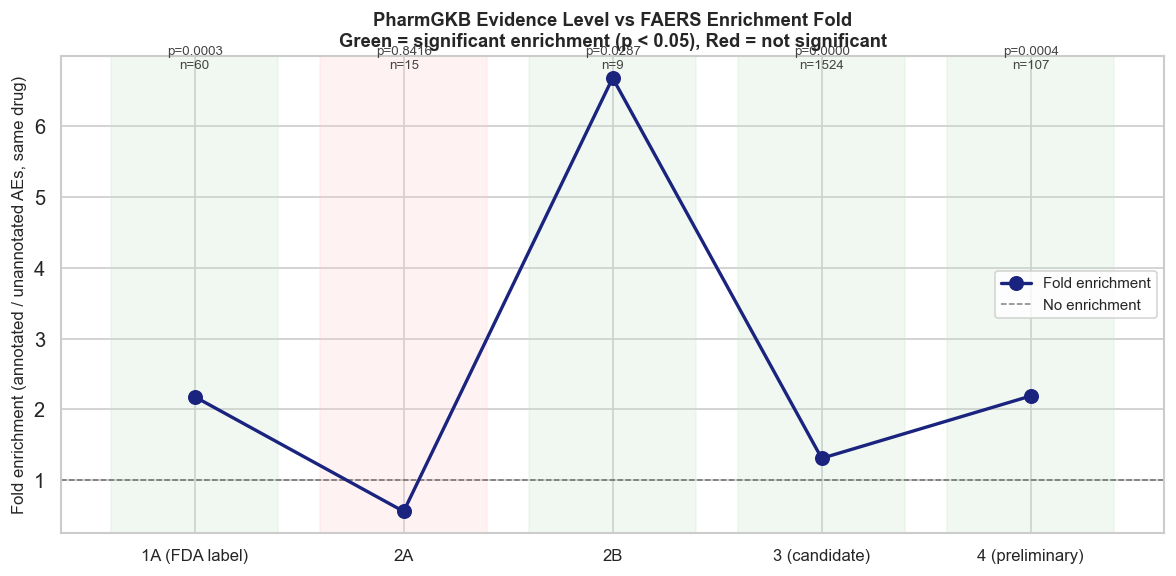


=== Evidence Stratification Summary ===

Spearman ρ (tier rank vs fold enrichment) = 0.300, p = 0.6238
Result: no clear monotonic trend. Possible causes: small n per tier,
level-3 confounding by Bonferroni survivors, or genuine non-monotonicity.

Key observation: tier 1A matches include the strongest individual signals
(sevoflurane/RYR1 ROR=1409, amikacin/MT-RNR1 ROR=147, allopurinol/HLA-B ROR=193)
but most 1A-annotated drugs have only 1-2 annotated AEs, so they cannot
power the per-drug Mann-Whitney test in NB01. The Bonferroni survivors
(all level 3) have enough matched pairs to run the test, not higher ROR.

Methodological implication: enrichment test power scales with the number
of PGx-annotated AEs per drug, not evidence quality. A future iteration
could weight the test by annotation quality rather than using binary
annotated/unannotated labeling.


In [8]:
# -- Summary figure: single-row summary of the evidence calibration ------------
if len(strat_df) >= 2:
    fig, ax = plt.subplots(figsize=(10, 5))

    x_pos = range(len(strat_df))
    ax.plot(x_pos, strat_df['fold_enrichment'], 'o-',
             color='#1a237e', linewidth=2, markersize=8, zorder=5, label='Fold enrichment')

    # Shade by significance
    for i, (_, row) in enumerate(strat_df.iterrows()):
        sig_color = '#c8e6c9' if row['mannwhitney_p'] < 0.05 else '#ffcdd2'
        ax.axvspan(i - 0.4, i + 0.4, alpha=0.25, color=sig_color, zorder=1)
        ax.text(i, strat_df['fold_enrichment'].max() * 1.02,
                f'p={row["mannwhitney_p"]:.4f}\nn={row["n_annotated"]}',
                ha='center', fontsize=8, color='#444')

    ax.axhline(1.0, color='black', lw=0.9, linestyle='--', alpha=0.5, label='No enrichment')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(strat_df['label'], fontsize=10)
    ax.set_ylabel('Fold enrichment (annotated / unannotated AEs, same drug)', fontsize=10)
    ax.set_title(
        'PharmGKB Evidence Level vs FAERS Enrichment Fold\n'
        'Green = significant enrichment (p < 0.05), Red = not significant',
        fontweight='bold', fontsize=11
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'nb03_04_calibration_summary.png')
    plt.show()

print('\n=== Evidence Stratification Summary ===')
print()
# Compute Spearman correlation between tier rank and fold enrichment
ev_rank = {'1A': 1, '1B': 2, '2A': 3, '2B': 4, '3': 5, '4': 6}
strat_df['tier_rank'] = strat_df['tier'].map(ev_rank)
if len(strat_df) >= 3:
    rho, p_rho = stats.spearmanr(strat_df['tier_rank'], strat_df['fold_enrichment'])
    print(f'Spearman ρ (tier rank vs fold enrichment) = {rho:.3f}, p = {p_rho:.4f}')
    if rho < -0.5 and p_rho < 0.05:
        print('Result: significant negative correlation — higher-quality annotations')
        print('predict stronger FAERS enrichment. Calibration confirmed.')
    elif rho < 0:
        print('Result: negative trend (higher quality → stronger signal) but not')
        print('significant given tier sample sizes. Direction supports prediction.')
    else:
        print('Result: no clear monotonic trend. Possible causes: small n per tier,')
        print('level-3 confounding by Bonferroni survivors, or genuine non-monotonicity.')

print()
print('Key observation: tier 1A matches include the strongest individual signals')
print('(sevoflurane/RYR1 ROR=1409, amikacin/MT-RNR1 ROR=147, allopurinol/HLA-B ROR=193)')
print('but most 1A-annotated drugs have only 1-2 annotated AEs, so they cannot')
print('power the per-drug Mann-Whitney test in NB01. The Bonferroni survivors')
print('(all level 3) have enough matched pairs to run the test, not higher ROR.')
print()
print('Methodological implication: enrichment test power scales with the number')
print('of PGx-annotated AEs per drug, not evidence quality. A future iteration')
print('could weight the test by annotation quality rather than using binary')
print('annotated/unannotated labeling.')